# PCA on the Cancer-Dataset

This notebook shows how PCA can compress the breast-cancer dataset and how the reduced features affect classification.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()

scaler = StandardScaler()
scaler.fit(cancer.data)
X = scaler.transform(cancer.data)
y = cancer.target
print("Data dimensionality", X.shape)

Data dimensionality (569, 30)


In [7]:
# Its 30 dimensional Data
import pandas as pd
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
display(data)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
print(X_train.shape)
print(y_train.shape)

knn= KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Score in Test", knn.score(X_test, y_test))

(426, 30)
(426,)
Score in Test 0.9440559440559441


In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X_train)
X_pca_train = pca.transform(X_train)
X_pca_test = pca.transform(X_test)

print("Data dimensionality", X_pca_train.shape)

Data dimensionality (426, 10)


In [21]:
knn= KNeighborsClassifier(n_neighbors=1)
knn.fit(X_pca_train, y_train)

print("Score in Test", knn.score(X_pca_test, y_test))

Score in Test 0.951048951048951


**Apply PCA to ceate 2D Data**

Reduce the standardized cancer data with PCA so you can inspect how much structure remains in fewer dimensions.

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
pca.fit(X)
X_pca = pca.transform(X)
print("Data dimensionality", X_pca.shape)

Data dimensionality (569, 5)


**Plot the data also using the labels**

Use the class labels to see whether the PCA projection still separates the two classes clearly.

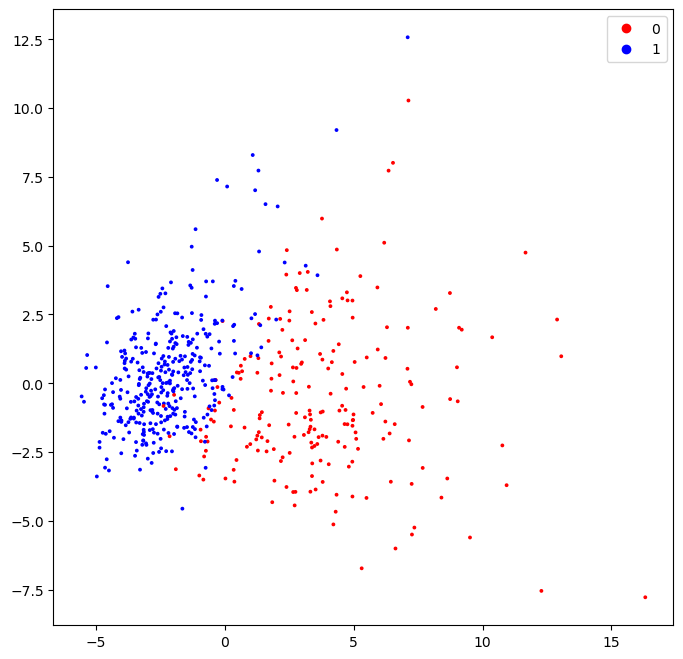

In [29]:
import mglearn;
import matplotlib.pyplot as plt;
import matplotlib as mpl;

plt.figure(figsize=(8,8))
colours = mpl.colors.ListedColormap(['r','b'])
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],c=y, s=3, cmap=colours)
plt.legend(*scatter.legend_elements())


In [30]:
#pca.components_
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768])

<BarContainer object of 5 artists>

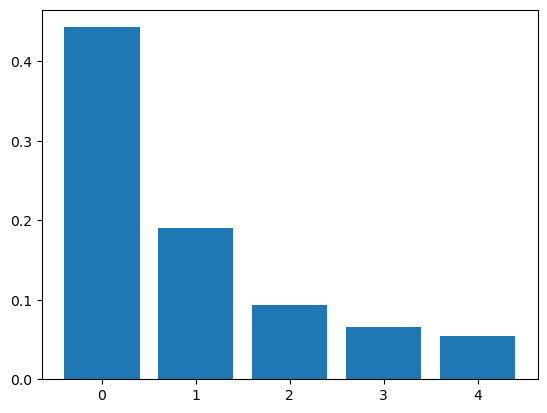

In [31]:
import numpy as np
plt.bar(np.arange(len(pca.explained_variance_ratio_)), 
         pca.explained_variance_ratio_)